# Sentinel Grid ML & Threat Analysis Notebook
#### Unsupervised Clustering & Anomaly Detection on Network and Honeypot Data
---
This notebook implements the first version of the machine learning threat analysis pipeline for Sentinel Grid. It serves as both a research prototype and a technical foundation that will later be converted into production ready Python modules for backend integration
This represents the first end-to-end implementation of our ML pipeline.

Its purpose is to:
- Process raw honeypot attack data
- Convert event-level logs into session-level behavioral features
- Analyze feature distributions
- Establish a baseline anomaly detection model
- Define and identify “bot-like” behavior

For my role as ML & Threat Analysis Engineer, I focus on:
- Extracting meaningful behavioral features from raw logs
- Detecting anomalous and automated behavior
- Identifying sessions that are “bot-like”
- Preparing ML outputs for backend consumption

Since honeypot logs don't include labeled ground truth, I decided on using an anomaly detection (unsupervised learning) approach. Anomaly detection identifies sessions that statistically deviate from normal system behavioral patterns. 

The assumption is:
- Most sessions represent baseline behavior
- Rare and statistically extreme sessions are more likely to be malicious
- We also have the option to add on clustering to categorize attack types.
---

### Pipeline
1. Load data  
2. Clean and parse timestamps  
3. Sessionize attacker activity  
4. Compute session-level features  
5. Plot feature distributions  
6. Train clustering/anomaly model  
7. Evaluate results  
8. Save outputs (CSV/JSON)

---

### Datasets Used

To design and validate the pipeline, I used two publicly available datasets. Information to download them are in `machine-learning/data/READ.me`

- Structured Network Intrusion Dataset: 
I will first evaluate our clustering workflow on the CIC-IDS2017 intrusion dataset:  
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset  
This dataset contains labeled network traffic including both normal activity and multiple cyberattacks (brute force, DoS, infiltration), making it a common benchmark for intrusion detection research and anomaly analysis. There is no passworda adn command level info, but to create a rough human baseline, we use the BENIGN portion of this labeled network intrusion dataset by training the anomaly model on BENIGN flows only.

- Zenodo CyberLab Honeynet Dataset:
Next, I will apply our pipeline to real honeypot data from:  
https://zenodo.org/records/3687527    
This dataset contains real attacker interaction logs (connect, auth attempts, commands, etc.) with timestamps and session_id and will be used to train and validate feature extraction on realistic attacker sessions. Used for attacker behvaior modeling. 


Together, these datasets allow us to validate the workflow on structured intrusion data and then apply it to realistic honeypot logs, preparing the pipeline for future deployment on our team’s own SentinelGrid honeypot data.



In [1]:
#uncomment to check which python version/enviornment is running script 
#import sys
#print(sys.executable)

#imports
import os
import json
import gzip
import math
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA



### Shannon Entropy 
Shannon entropy measures password strength in bits, representing min number of guesses needed to guess it.

The Shannon entropy is defined as:
$$
H = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i)
$$

where:
- $p(x_i)$ is the probability of character $x_i$ in the password  
- $n$ is the number of unique characters  

This helps us measure how unpredictable a password string is.

- Higher entropy → more randomness → more human-like
- Medium entropy → common human style passwords
- Lower entropy → repetitive/simple → more bot-like

<u> Character distribution entropy:</u> Instead of estimating entropy from the allowed character pool, we compute it from the actual characters used. This better captures repetition patterns, structured guesses, and dictionary based attacks.

In our pipeline, entropy is computed per password attempt and can be aggregated per session (mean entropy or maximum entropy) to characterize attacker behavior.


In [2]:
def shannon_entropy(s:str) ->float:
    #handles missing values or nons trings
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return 0.0
    
    s=str(s)
    if len(s) == 0:
        return 0.0
        
    #counts how many times each character appears
    #stored in dict - ex: "aab1"-> {'a':2, 'b':1, '1':1}
    counts= {}
    for ch in s:
        counts[ch]= counts.get(ch, 0)+1
    
    #compute probability by dividing count by total length of string
    #ex: [2,1,1]/4 -> [0.5, 0.25, 0.25]
    probs= np.array(list(counts.values()), dtype=float)/ len(s)
    #apply shannon entropy formula 
    #measures how unpredictable the character distribution is
    entropy= -(probs*np.log2(probs)).sum()

    #low values -> low entropy 
    #high values -> high entropy 
    return float(entropy)

### Network Intrusion Dataset

Help debug and verify preprocessing + ML steps before using honeypot logs.
Purpose:
- We use BENIGN flow as a rough baseline for normal behavior and network baseline
- Train anomaly model only on BENIGN
- Note: This dataset is flow level, so there is no password data or specific commands. Password entropy is set to 0 for this dataset 

In [3]:
#path for network intrustion data
NETWORK_DIR = Path("../data/Kaggle CIC-IDS-2017")
csv_files = sorted(NETWORK_DIR.glob("*.pcap_ISCX.csv"))

#prints found CSV files
print("CSV files:", len(csv_files))
for f in csv_files[:8]:
    print(" -", f.name)

#combines all dataset into one large data frame
dfs= []
for f in csv_files:
    df= pd.read_csv(f)
    dfs.append(df)

net_df= pd.concat(dfs, ignore_index=True)
print("Network shape:", net_df.shape)
print("Columns:", len(net_df.columns))
#Network shape: (2830743, 79)
#Columns: 79
#show some rows of the dataset 
#net_df.head()
net_df.sample(10)

CSV files: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
Network shape: (2830743, 79)
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1135897,53,155466,2,2,70,404,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
26691,80,117404,3,5,26,11607,20,0,8.666667,10.263203,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
1108897,53,135769,2,2,78,334,39,39,39.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1925026,443,2224630,10,7,510,2834,206,0,51.000000,80.578464,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2424460,51476,116230272,6,6,11595,389,7240,0,1932.500000,2848.073577,...,32,11968.0,0.0,11968,11968,58100000.0,59500000.0,100000000,16000000,BENIGN
2828230,35737,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
711504,53,30648,1,1,51,67,51,51,51.000000,0.000000,...,40,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1197042,53,230,2,2,82,254,41,41,41.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
859434,443,79356770,17,17,1373,5387,504,0,80.764706,133.842505,...,20,274339.0,0.0,274339,274339,45001085.0,0.0,45001085,45001085,BENIGN
1256293,80,15176,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Converting raw data from the network flow into features to help differentiate between normal and attack. Ended up adding more features and values to build a better baseline.


In [4]:
#clean col names and check for required cols for features
net_df.columns= [c.strip() for c in net_df.columns]
required_cols = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "SYN Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "Packet Length Mean",
    "Packet Length Std",
    "Down/Up Ratio",
    "Label"
]
missing= [c for c in required_cols if c not in net_df.columns]
if missing:
    raise ValueError(f"Missing req cols: {missing}")

#convert time to secs 
dur_us= pd.to_numeric(net_df["Flow Duration"], errors="coerce")
session_duration_s= dur_us / 1e6 

#packet count
fwd_pkts= pd.to_numeric(net_df["Total Fwd Packets"], errors="coerce").fillna(0.0)
bwd_pkts= pd.to_numeric(net_df["Total Backward Packets"], errors="coerce").fillna(0.0)
packet_count= (fwd_pkts+bwd_pkts)

net_features = pd.DataFrame({
    "session_duration_s": session_duration_s,
    "packet_count": packet_count,
})

#packets per min 
#ignore flows shorter than 10 ms for rate computation
MIN_DUR_S= 0.01  
valid= net_features["session_duration_s"]>= MIN_DUR_S

net_features["packets_per_min"]= 0.0
net_features.loc[valid, "packets_per_min"]=(
    net_features.loc[valid, "packet_count"]/(net_features.loc[valid, "session_duration_s"]/60.0)
)

extra_numeric_cols= [
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "SYN Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "Packet Length Mean",
    "Packet Length Std",
    "Down/Up Ratio",
]

for col in extra_numeric_cols:
    net_features[col] = pd.to_numeric(net_df[col], errors="coerce").fillna(0.0)

#no pass data in this data
net_features["avg_password_entropy"]= 0.0

#get labels
net_labels = net_df["Label"].astype(str)

#cleanup and fill any missing values with 0
net_features.replace([np.inf, -np.inf], np.nan, inplace=True)
net_features.fillna(0.0, inplace=True)

print("Feature data frame shape:", net_features.shape)
net_features.describe()

Feature data frame shape: (2830743, 14)


,session_duration_s,packet_count,packets_per_min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,SYN Flag Count,RST Flag Count,FIN Flag Count,Packet Length Mean,Packet Length Std,Down/Up Ratio,avg_password_entropy
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0
mean,1.478566e+01,1.975493e+01,1.685272e+03,1.490208e+06,7.078247e+04,1.298449e+06,2.919271e+06,4.644646e-02,2.423392e-04,3.537976e-02,1.719444e+02,2.949756e+02,6.835004e-01,0.0
std,3.365374e+01,1.746663e+03,5.021521e+03,2.592706e+07,2.542966e+05,4.507944e+06,8.045870e+06,2.104500e-01,1.556536e-02,1.847378e-01,3.054915e+02,6.318001e+02,6.804920e-01,0.0
min,-1.300000e-05,2.000000e+00,0.000000e+00,-2.610000e+08,-2.000000e+06,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.550000e-04,2.000000e+00,0.000000e+00,1.191355e+02,3.341404e+00,6.366667e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.131600e-02,4.000000e+00,1.251872e+01,4.569281e+03,1.082163e+02,1.143884e+04,1.371787e+02,0.000000e+00,0.000000e+00,0.000000e+00,5.720000e+01,2.598076e+01,1.000000e+00,0.0
75%,3.204829e+00,8.000000e+00,1.670359e+03,1.649485e+05,2.325581e+04,3.374266e+05,6.912663e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.198000e+02,1.743239e+02,1.000000e+00,0.0
max,1.200000e+02,5.116810e+05,5.250764e+05,2.071000e+09,4.000000e+06,1.200000e+08,8.480026e+07,1.000000e+00,1.000000e+00,1.000000e+00,3.337143e+03,4.731522e+03,1.560000e+02,0.0


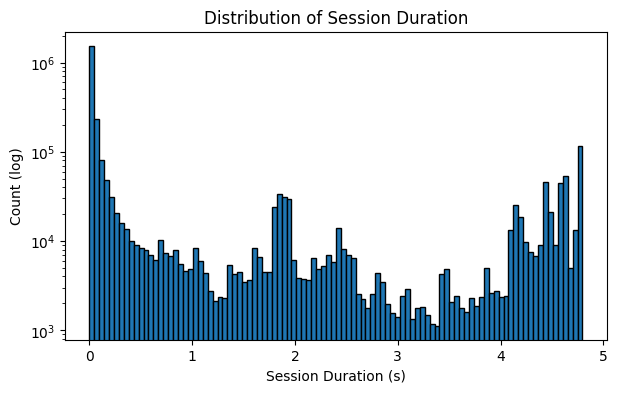

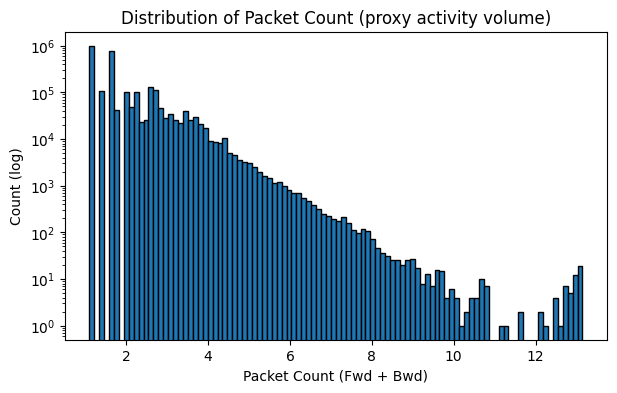

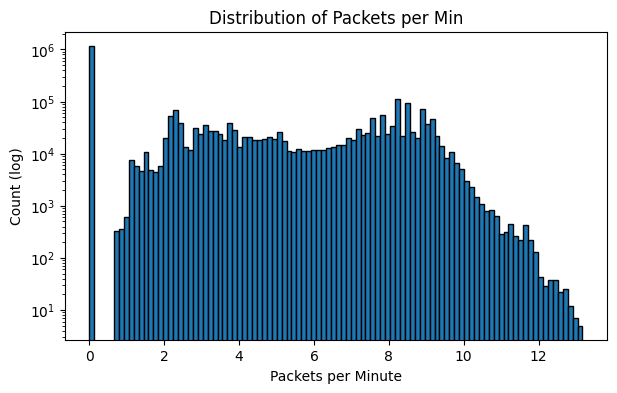

In [5]:
#log transform heavy tailed features
log_cols=[
    "session_duration_s",
    "packet_count",
    "packets_per_min",
    "Flow Bytes/s",
    "Flow Packets/s",
]

for col in log_cols:
    if col in net_features.columns:
        net_features[col] = np.log1p(np.clip(net_features[col], 0, None))
        
#plot distributions
#session duration 
plt.figure(figsize=(7,4))
plt.hist(net_features["session_duration_s"], bins=100, edgecolor="black", log=True)
plt.xlabel("Session Duration (s)")
plt.ylabel("Count (log)")
plt.title("Distribution of Session Duration")
plt.show()

#packet counts
plt.figure(figsize=(7,4))
plt.hist(net_features["packet_count"], bins=100, edgecolor="black", log=True)
plt.xlabel("Packet Count (Fwd + Bwd)")
plt.ylabel("Count (log)")
plt.title("Distribution of Packet Count (proxy activity volume)")
plt.show()

#packets per min
plt.figure(figsize=(7,4))
plt.hist(net_features["packets_per_min"], bins=100, edgecolor="black", log=True)
plt.xlabel("Packets per Minute")
plt.ylabel("Count (log)")
plt.title("Distribution of Packets per Min")
plt.show()

### Human Baseline Model 
Train human baseline anomaly model using Isolation Forest to build baseline, assign anomaly scores, and plot distribution 

Total flows: 2830743
BENIGN flows: 2273097
Non BENIGN flows: 557646
Finished training baseline anomaly model on BENIGN flows only
Mean score BENIGN: 0.4266184957719508
Mean score non-BENIGN: 0.5154755072275718


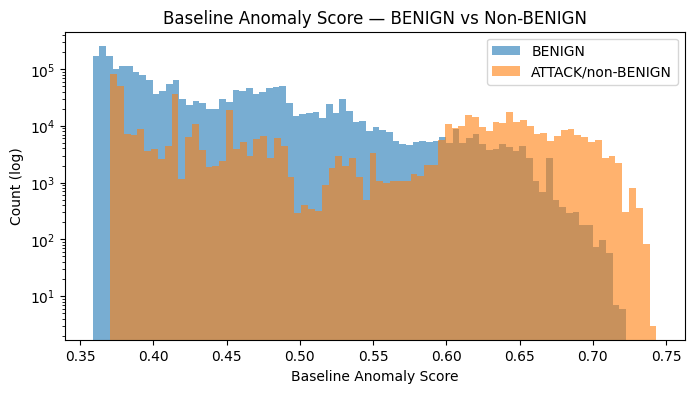

Evalutation Metrics:
ROC-AUC (BENIGN vs non-BENIGN) using baseline scores: 0.7113851484704602


In [6]:
feature_cols = list(net_features.columns)

#define BENIGN mask
benign_mask= net_labels.str.upper().eq("BENIGN")
print("Total flows:", len(net_features))
print("BENIGN flows:", int(benign_mask.sum()))
print("Non BENIGN flows:", int((~benign_mask).sum()))

#use BENIGN only for training data
X_benign = net_features.loc[benign_mask, feature_cols].copy()
#drop extreme outliers in BENIGN to make baseline tighter 
X_benign = X_benign.clip(lower=X_benign.quantile(0.001), upper=X_benign.quantile(0.999), axis=1)

baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("iso", IsolationForest(
        n_estimators=400,
        contamination=0.03,  
        random_state=42
    ))
])

#trainin on BENIGN to learn normal session durations, packet counts, and packet rates 
baseline_pipe.fit(X_benign)
print("Finished training baseline anomaly model on BENIGN flows only")

#score all flows using the BENIGN trained model
#compare how abnormal eeach session is with the baseline using anomaly scores
X_all= net_features[feature_cols].copy()

scores_all= -baseline_pipe.named_steps["iso"].score_samples(
    baseline_pipe.named_steps["scaler"].transform(X_all)
)

#high score= more abnormal
scored_net= net_features.copy()
scored_net["Label"] = net_labels
scored_net["baseline_anomaly_score"] = scores_all
scored_net["is_benign"] = benign_mask.astype(int)

print("Mean score BENIGN:", float(scored_net.loc[scored_net["is_benign"]==1, "baseline_anomaly_score"].mean()))
print("Mean score non-BENIGN:", float(scored_net.loc[scored_net["is_benign"]==0, "baseline_anomaly_score"].mean()))

#plot distributions
plt.figure(figsize=(8,4))
plt.hist(scored_net.loc[scored_net["is_benign"]==1, "baseline_anomaly_score"], bins=80, alpha=0.6, label="BENIGN", log=True)
plt.hist(scored_net.loc[scored_net["is_benign"]==0, "baseline_anomaly_score"], bins=80, alpha=0.6, label="ATTACK/non-BENIGN", log=True)
plt.xlabel("Baseline Anomaly Score")
plt.ylabel("Count (log)")
plt.title("Baseline Anomaly Score — BENIGN vs Non-BENIGN")
plt.legend()
plt.show()

print("Evalutation Metrics:")
#roc-auc score
#tells us how well the baseline scores separate non-benign samples from benign ones 
#if I randomly pick one non-benign sample and one benign sample, what is the probability that the model gives the non-benign one a higher score?
y = (~benign_mask).astype(int)  #1= non benign
auc = roc_auc_score(y, scores_all)
print("ROC-AUC (BENIGN vs non-BENIGN) using baseline scores:", auc)



### Zenodo CyberLab Honeynet Dataset
Stand-in data for our future SentinelGrid data. Allows us to test the pipeline and train an unsupervised model on honeypot sessions to learn attacker patterns and behavioral structure. 
- Validate real session parsing and feature extraction.
- Score honeynet sessions using the human baseline model.
- Cluster honeynet sessions to discover attacker behavior structure.

In [7]:
ZENODO_DIR= Path("../data/Zenodo Honeypot Data")  
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
def zenod_events(path:Path) ->Iterable[Dict[str,Any]]:
    with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)

            if isinstance(obj, list):
                for item in obj:
                    if isinstance(item, dict):
                        for _, events in item.items():
                            if isinstance(events, list):
                                for ev in events:
                                    if isinstance(ev, dict):
                                        yield ev
            elif isinstance(obj,dict):
                for _,events in obj.items():
                    if isinstance(events,list):
                        for ev in events:
                            if isinstance(ev,dict):
                                yield ev

def load_zenodo(max_events: int|None=None)-> pd.DataFrame:
    rows=[]
    seen=0

    for fpath in sorted(ZENODO_DIR.glob("*.json")):
        print("File:", fpath.name)
        for ev in zenod_events(fpath):
            rows.append(ev)
            seen+=1

            if max_events is not None and seen >= max_events:
                break
        if max_events is not None and seen >= max_events:
                break

    return pd.DataFrame(rows) 

zen_df= load_zenodo()
print("Columns:", zen_df.columns.tolist())
print("Total columns:", len(zen_df.columns))

print("Zendo Events:", zen_df.shape)
zen_df.head()


File: cowrie_2019-05-13.json
File: cowrie_2019-05-14.json
File: cowrie_2019-05-15.json
File: cowrie_2019-05-16.json
File: cowrie_2019-05-17.json
Columns: ['session_id', 'dst_host_identifier', 'eventid', 'timestamp', 'src_ip_identifier', 'dst_ip_identifier', 'message', 'protocol', 'src_port', 'sensor', 'geolocation_data', 'arch', 'duration', 'ssh_client_version', 'username', 'password', 'hasshAlgorithms', 'macCS', 'langCS', 'compCS', 'encCS', 'hassh', 'kexAlgs', 'keyAlgs', 'fingerprint', 'key', 'type', 'outfile', 'destfile', 'duplicate', 'shasum', 'url', 'ttylog', 'size', 'filename', 'data']
Total columns: 36
Zendo Events: (190670, 36)


,session_id,dst_host_identifier,eventid,timestamp,src_ip_identifier,dst_ip_identifier,message,protocol,src_port,sensor,geolocation_data,arch,duration,ssh_client_version,username,password,hasshAlgorithms,macCS,langCS,compCS,encCS,hassh,kexAlgs,keyAlgs,fingerprint,key,type,outfile,destfile,duplicate,shasum,url,ttylog,size,filename,data
0,0b74e20e,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.connect,2019-05-13T00:01:29.572648Z,2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e,None,New connection: 2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e:48988 (172.22.0.2:2222) [session: 0b74e20e],None,48988.0,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
1,0b74e20e,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.closed,2019-05-13T00:01:29.711210Z,2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e,None,Connection lost after 0 seconds,None,NaN,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '2249962791c288cfc8837b71ef30564df08eaea8149fe8350494861272ad564e', 'longitude': -8.95, 'city_name': 'Macroom'}",None,0.137386,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
2,d54146f3,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.session.connect,2019-05-13T00:01:29.626202Z,276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9,None,New connection: 276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9:39175 (172.22.0.2:2222) [session: d54146f3],None,39175.0,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,NaN,None,None,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN
3,d54146f3,0b6413ddbb3aebd1e5b4f226a60016af8c6138386a8195d453c7dbda2cbbef38,cowrie.client.version,2019-05-13T00:01:30.104744Z,276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9,None,Remote SSH version: SSH-2.0-Go,None,NaN,2ff702a541a4,"{'country_name': 'Ireland', 'continent_code': 'EU', 'timezone': 'Europe/Dublin', 'region_code': 'CO', 'country_code2': 'IE', 'location': {'lon': -8.95, 'lat': 51.9}, 'region_name': 'County Cork', 'latitude': 51.9, 'country_code3': 'IE', 'ip': '276e3404ff11c86dedd38a132514e826dedfd9841f0bbc74a87db66d84f74fb9', 'longitude': -8.95, 'city_name': 'Macroom'}",None,NaN,SSH-2.0-Go,NaN,NaN,None,"[hmac-sha2-256-etm@openssh.com, hmac-sha2-256, hmac-sha1, hmac-sha1-96]",None,[none],"[aes128-ctr, aes192-ctr, aes256-ctr, aes128-gcm@openssh.com, arcfour256, arcfour128, aes128-cbc, arcfour, 3des-cbc]",None,"[curve25519-sha256@libssh.org, ecdh-sha2-nistp256, ecdh-sha2-nistp384, ecdh-sha2-nistp521, diffie-hellman-group14-sha1, diffie-hellman-group1-sha1]","[ssh-rsa-cert-v01@openssh.com, ssh-dss-cert-v01@openssh.com, ecdsa-sha2-nistp256-cert-v01@openssh.com, ecdsa-sha2-nistp384-cert-v01@openssh.com, ecdsa-sha2-nistp521-cert-v01@openssh.com, ssh-ed25519-cert-v01@openssh.com, ecdsa-sha2-nistp256, ecdsa-sha2-nistp384, ecdsa-sha2-nistp521, ssh-rsa, ssh-dss,

### Feature extraction from session elements
Compute core behavioral features:
- session_duration_s: last timestamp - first timestamp
- command_count: number of "command-like" events (based on eventid)
- commands_per_min: command_count / duration
- avg_password_entropy: mean entropy across attempted passwords within a session

In [8]:
#parse time and event type

zen_df["timestamp"]= pd.to_datetime(zen_df["timestamp"],errors="coerce", utc=True)
print("Null timestamps:", int(zen_df["timestamp"].isna().sum()))

zen_df["eventid"].value_counts().head(15)

#session feature extraction


Null timestamps: 0


eventid
cowrie.session.connect          40879
cowrie.session.closed           40879
cowrie.direct-tcpip.request     32851
cowrie.client.version           27975
cowrie.login.success            26398
cowrie.login.failed              9030
cowrie.direct-tcpip.data         8683
cowrie.command.success           2853
cowrie.log.open                   504
cowrie.session.file_download      260
cowrie.log.closed                 239
cowrie.client.fingerprint          70
cowrie.client.size                 39
cowrie.command.failed              10
Name: count, dtype: int64

In [9]:
df= zen_df.copy()

for col in ["session_id", "timestamp", "eventid", "password"]:
    if col not in df.columns:
        df[col]= None

df= df.dropna(subset=["timestamp"])
feats=[]

for session_id, g in df.groupby("session_id"):
    start= g["timestamp"].min()
    end=g["timestamp"].max()
    duration_s=(end-start).total_seconds()

    # command count (based on event type)
    cmd_count = int(np.sum(
        g["eventid"].apply(
            lambda x: isinstance(x, str) and ("cowrie.command" in x)
        )
    ))

    pw_series= g["password"].dropna()
    entropies= [shannon_entropy(pw) for pw in pw_series.tolist()]
    avg_entropy= float(np.mean(entropies)) if len(entropies) else 0.0 

    #avoid dividing by 0
    MIN_DUR_S= 0.5
    if duration_s <MIN_DUR_S:
        if duration_s==0:
            cmds_per_min= 0.0
        else:
            cmds_per_min= cmd_count/(MIN_DUR_S/60.0)
    else:
        cmds_per_min=cmd_count/(duration_s/60.0)
    
    feats.append({
        "session_id": session_id,
        "start_time": start,
        "end_time": end,
        "session_duration_s": duration_s,
        "command_count": cmd_count,
        "commands_per_min": cmds_per_min,
        "avg_password_entropy": avg_entropy,
    })

zen_sessions= pd.DataFrame(feats)
zen_sessions.replace([np.inf, -np.inf], np.nan, inplace=True)
zen_sessions.fillna(0.0, inplace=True)
print("Zenodo session features shape:", zen_sessions.shape)
zen_sessions.head()
    

Zenodo session features shape: (40874, 7)


,session_id,start_time,end_time,session_duration_s,command_count,commands_per_min,avg_password_entropy
0,00002bde,2019-05-14 22:50:11.791287+00:00,2019-05-15 01:04:44.980779+00:00,8073.189492,0,0.0,2.321928
1,00019043,2019-05-15 20:56:56.041824+00:00,2019-05-15 20:56:57.117749+00:00,1.075925,0,0.0,2.321928
2,00026a37,2019-05-16 14:30:02.466333+00:00,2019-05-16 14:30:03.394699+00:00,0.928366,0,0.0,2.321928
3,0002ff7b,2019-05-14 19:27:02.225593+00:00,2019-05-14 19:27:03.609317+00:00,1.383724,0,0.0,2.321928
4,00035ea9,2019-05-13 00:43:41.449767+00:00,2019-05-13 00:43:42.383863+00:00,0.934096,0,0.0,2.321928


### Plot distributions

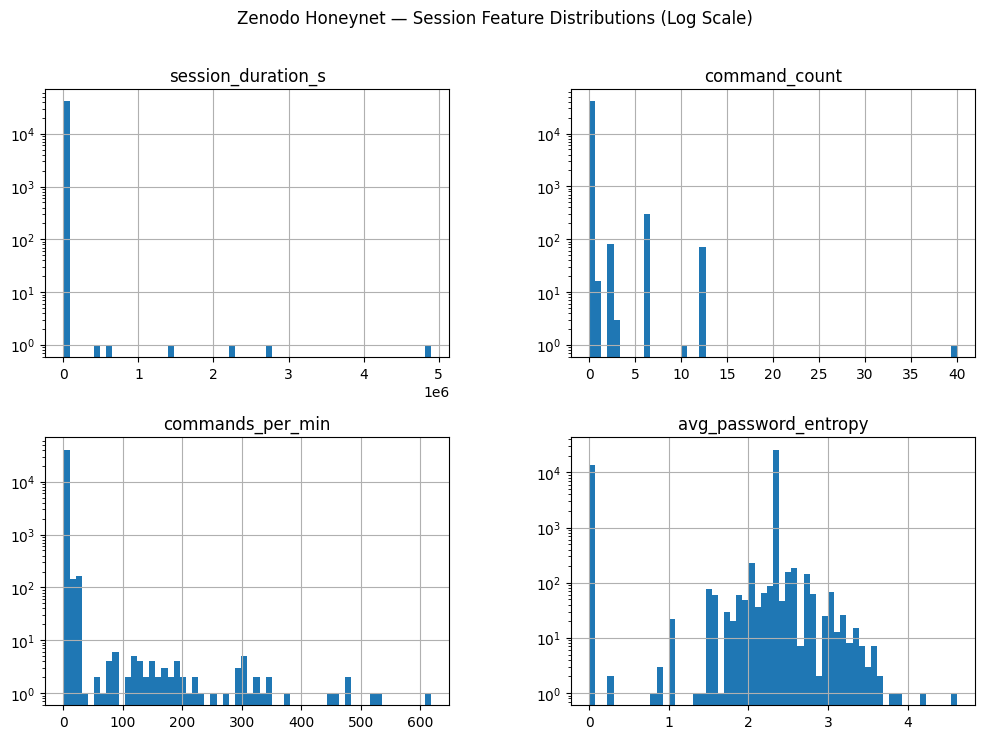

In [10]:
zen_cols = ["session_duration_s", "command_count", "commands_per_min", "avg_password_entropy"]
zen_sessions[zen_cols].hist(bins=60, figsize=(12,8), log=True)
plt.suptitle("Zenodo Honeynet — Session Feature Distributions (Log Scale)")
plt.show()

### Attacker Behavior Model
Features, optimal clustering, behavior profiles
- We train an attacker behavior model on Zenodo sessions using KMeans unsupervised learning


In [11]:
zen_cols=[
    "session_duration_s",
    "command_count",
    "commands_per_min",
    "avg_password_entropy"
]
X_attack= zen_sessions[zen_cols].copy()
X_attack.replace([np.inf, -np.inf], np.nan, inplace=True)
X_attack.fillna(0.0, inplace=True)

X_attack.describe()

,session_duration_s,command_count,commands_per_min,avg_password_entropy
count,4.087400e+04,40874.000000,40874.000000,40874.000000
mean,3.851772e+02,0.070045,0.551318,1.558080
std,3.108416e+04,0.747114,10.639579,1.095698
min,3.106000e-03,0.000000,0.000000,0.000000
25%,2.289495e-01,0.000000,0.000000,0.000000
50%,1.046549e+00,0.000000,0.000000,2.321928
75%,2.424398e+00,0.000000,0.000000,2.321928
max,4.900003e+06,40.000000,618.220504,4.612649


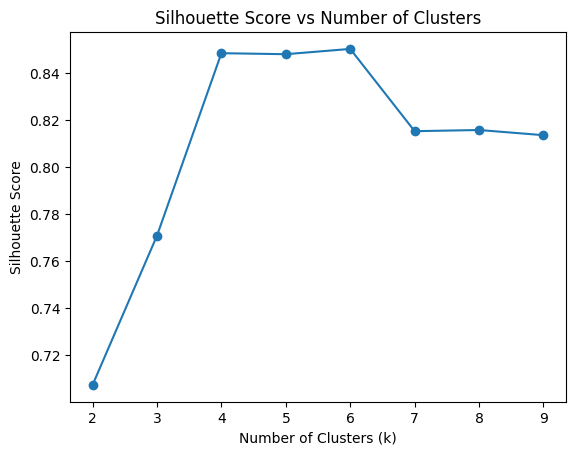

Best k: 6


In [12]:
for col in zen_cols:
    X_attack[col]= np.log1p(X_attack[col])

scaler_attack= StandardScaler()
X_attack_scaled= scaler_attack.fit_transform(X_attack)

sil_scores=[]
k_range= range(2,10)

for k in k_range:
    km=KMeans(n_clusters =k, random_state=42)
    labels= km.fit_predict(X_attack_scaled)
    score= silhouette_score(X_attack_scaled, labels)
    sil_scores.append(score)

plt.plot(k_range,sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

print("Best k:", k_range[np.argmax(sil_scores)])


In [13]:
k_opt= k_range[np.argmax(sil_scores)]

kmeans_attack= KMeans(n_clusters=k_opt, random_state=42)
zen_sessions["attack_cluster"]= kmeans_attack.fit_predict(X_attack_scaled)

print("Cluster counts:")
print(zen_sessions["attack_cluster"].value_counts().sort_index())
cluster_summary = zen_sessions.groupby("attack_cluster")[zen_cols].agg(["count", "mean", "median"])
cluster_summary

Cluster counts:
attack_cluster
0    13268
1    24771
2       71
3      486
4      373
5     1905
Name: count, dtype: int64


session_duration_s                            command_count  \
                            count          mean       median         count   
attack_cluster                                                               
0                           13268      0.245326     0.157400         13268   
1                           24771      2.348433     1.215439         24771   
2                              71      4.679223     4.000330            71   
3                             486  31718.265958  7104.911532           486   
4                             373     26.279021    15.210344           373   
5                            1905    134.956923   170.637565          1905   

                                 commands_per_min                            \
                     mean median            count          mean      median   
attack_cluster                                                                
0                0.000000    0.0            13268  0.000000e+00    0.000000   
1                0.000000    0.0            24771  0.000000e+00    0.000000   
2               12.000000   12.0               71  2.156388e+02  179.985151   
3                0.012346    0.0              486  2.680679e-07    0.000000   
4                5.297587    6.0              373  1.934264e+01   19.318430   
5                0.015223    0.0             1905  4.930496e-03    0.000000   

               avg_password_entropy                      
                              count      mean    median  
attack_cluster                                           
0                             13268  0.000022  0.000000  
1                             24771  2.322952  2.321928  
2                                71  2.689574  2.750000  
3                               486  2.322136  2.321928  
4                               373  2.040333  2.521641  
5                              1905  2.132422  2.321928

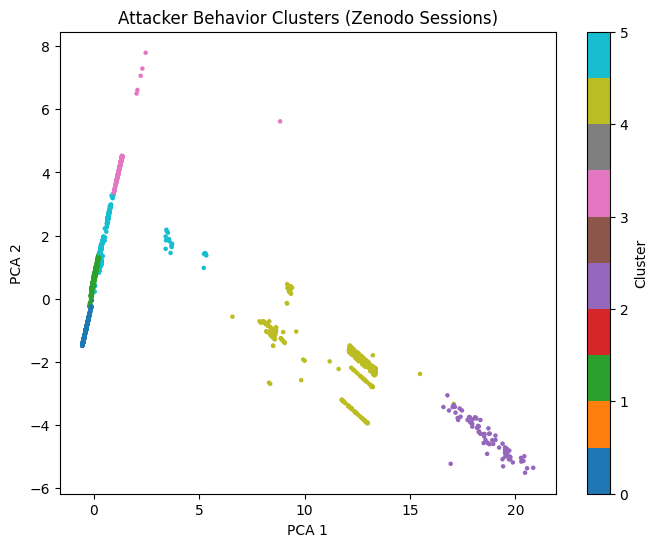

In [14]:
def label_cluster(row):
    if row["command_count"]<2:
        return "Scanner / Probe"
    elif row["avg_password_entropy"]>3:
        return "Brute Force / Credential Stuffing"
    elif row["commands_per_min"]>10:
        return "High Automation Bot"
    else:
        return "Interactive / Manual"

cluster_labels= {}

for cid in zen_sessions["attack_cluster"].unique():
    subset = zen_sessions[zen_sessions["attack_cluster"] == cid]
    avg = subset[zen_cols].mean()
    cluster_labels[cid]= label_cluster(avg)

zen_sessions["attack_type"]= zen_sessions["attack_cluster"].map(cluster_labels)

zen_sessions[["attack_cluster", "attack_type"]].drop_duplicates().sort_values("attack_cluster")

pca= PCA(n_components=2)
X_pca= pca.fit_transform(X_attack_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=zen_sessions["attack_cluster"], cmap="tab10", s=5)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Attacker Behavior Clusters (Zenodo Sessions)")
plt.colorbar(label="Cluster")
plt.show()